# Przygotowanie danych

In [1]:
import pandas as pd
import numpy as np
import os
import glob

print("="*80)
print(">>> INICJALIZACJA DANYCH: STRATYFIKOWANE ŁADOWANIE <<<")
print("="*80)

# Wzorce plików i parametry
ALL_FILES_PATTERN = "../dane/treningowe/*_netflow-extended.csv" 
SAMPLE_SIZE_PER_FILE = 15000 
RANDOM_SEED = 42

def load_stratified_data(file_pattern, sample_size=10000):
    files = glob.glob(file_pattern)
    dfs = []
    
    print(f"[*] Znaleziono plików: {len(files)}. Rozpoczynam pobieranie próbek...")
    
    for path in files:
        try:
            df_temp = pd.read_csv(path, on_bad_lines="skip", low_memory=False)
            
            # Losowanie (Stratyfikacja)
            if len(df_temp) > sample_size:
                df_sampled = df_temp.sample(n=sample_size, random_state=RANDOM_SEED)
            else:
                df_sampled = df_temp
                
            # Zapisanie źródła i dodanie do listy
            filename = os.path.basename(path)
            df_sampled['original_file'] = filename
            dfs.append(df_sampled)
            print(f"  + {filename}: pobrano {len(df_sampled)} wierszy (z {len(df_temp)})")
            
        except Exception as e:
            print(f"  [ERR] {path}: {e}")
            
    if not dfs: 
        print("[!] Nie znaleziono danych pasujących do wzorca.")
        return pd.DataFrame()
    
    final_df = pd.concat(dfs, ignore_index=True)
    final_df.dropna(axis=1, how='all', inplace=True)
    
    if 'StartTime' in final_df.columns:
        final_df.sort_values(by='StartTime', inplace=True)
        
    return final_df

# 1. Zbiór Treningowy
df_train = load_stratified_data("../dane/treningowe/*geo-1*.csv", sample_size=20000)
print(f"\n[+] Zbiór treningowy gotowy: {df_train.shape}")

# 2. Zbiór Testowy 
df_test = load_stratified_data("../dane/testowe/*geo-1*.csv", sample_size=20000)
print(f"[+] Zbiór testowy gotowy: {df_test.shape}")

# Ujednolicenie kolumn
common_cols = df_train.columns.intersection(df_test.columns)
df_train = df_train[common_cols].copy()
df_test = df_test[common_cols].copy()

>>> INICJALIZACJA DANYCH: STRATYFIKOWANE ŁADOWANIE <<<
[*] Znaleziono plików: 7. Rozpoczynam pobieranie próbek...
  + 2021-04-26_honeypot-cloud-digitalocean-geo-1_netflow-extended.csv: pobrano 10840 wierszy (z 10840)
  + 2021-04-27_honeypot-cloud-digitalocean-geo-1_netflow-extended.csv: pobrano 10262 wierszy (z 10262)
  + 2021-04-28_honeypot-cloud-digitalocean-geo-1_netflow-extended.csv: pobrano 10948 wierszy (z 10948)
  + 2021-04-29_honeypot-cloud-digitalocean-geo-1_netflow-extended.csv: pobrano 10102 wierszy (z 10102)
  + 2021-04-30_honeypot-cloud-digitalocean-geo-1_netflow-extended.csv: pobrano 7765 wierszy (z 7765)
  + 2021-05-01_honeypot-cloud-digitalocean-geo-1_netflow-extended.csv: pobrano 7389 wierszy (z 7389)
  + 2021-05-02_honeypot-cloud-digitalocean-geo-1_netflow-extended.csv: pobrano 8459 wierszy (z 8459)

[+] Zbiór treningowy gotowy: (65765, 95)
[*] Znaleziono plików: 1. Rozpoczynam pobieranie próbek...
  + 2021-05-20_honeypot-cloud-digitalocean-geo-1_netflow-extended.csv:

# Feature Engineering

In [2]:
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

print("="*80)
print(">>> KROK 2: INŻYNIERIA CECH I PCA  <<<")
print("="*80)

# ==========================================
# KONFIGURACJA CECH 
# ==========================================
NUM_COLS = [
    'Dur', 'TotPkts', 'SrcPkts', 'DstPkts', 'TotBytes', 'SrcBytes', 'DstBytes', 
    'Bytes_per_Pkt', 'Pkts_Ratio', 'Pkts_Freq', 'Bytes_Ratio'
]

BIN_COLS = [
    'argus_src_loss', 'argus_dst_loss', 'argus_encap', 'argus_mismatch',
    'is_well_known_port', 'is_ephemeral_port'
]

TARGET_PORTS = [
    21, 22, 23, 3389, 5900, 80, 443, 8080, 8081, 8888, 3128, 1080,
    25, 53, 110, 143, 1433, 3306, 5432, 6379, 27017,
    445, 139, 2323, 5060, 5061, 500, 4500, 123, 1900, 5353, 5683
]

# ==========================================
# FUNKCJE PRZETWARZAJĄCE
# ==========================================
def clean_and_engineer_baseline(df, valid_states, valid_protos):
    df = df.copy()
    
    # 1. Rzutowanie numeryczne
    for c in ['Sport', 'Dport', 'TotBytes', 'TotPkts', 'SrcPkts', 'DstPkts', 'SrcBytes', 'DstBytes', 'Dur']:
        if c in df.columns: 
            df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)
            
    # 2. Fizyka i Asymetria
    df['Bytes_per_Pkt'] = df['TotBytes'] / (df['TotPkts'] + 1e-6)
    df['Pkts_Ratio']    = df['SrcPkts'] / (df['DstPkts'] + 1e-6)
    df['Pkts_Freq']     = df['TotPkts'] / (df['Dur'] + 1e-6)
    df['Bytes_Ratio']   = df.get('SrcBytes', 0) / (df.get('DstBytes', 0) + 1e-6)
    
    # 3. Flagi Portów (Ogólne)
    df['is_well_known_port'] = ((df['Dport'] > 0) & (df['Dport'] <= 1024)).astype(int)
    df['is_ephemeral_port'] = (df['Dport'] >= 49152).astype(int)

    # 4. Twarde kodowanie kluczowych portów
    for p in TARGET_PORTS: 
        df[f'is_dport_{p}'] = (df['Dport'] == p).astype(int)
        
    # 5. Flagi Argusa
    if 'Flgs' in df.columns:
        flgs = df['Flgs'].astype(str).str.lower()
        df['argus_src_loss'] = flgs.apply(lambda x: 1 if 's' in x else 0)
        df['argus_dst_loss'] = flgs.apply(lambda x: 1 if 'd' in x else 0)
        df['argus_encap']    = flgs.apply(lambda x: 1 if 'e' in x else 0)
        df['argus_mismatch'] = flgs.apply(lambda x: 1 if '*' in x else 0)
    else:
        for c in BIN_COLS: 
            if c not in df.columns: df[c] = 0
            
    # 6. Kategoryzacja State/Proto (redukcja szumu)
    if 'State' in df.columns:
        df['State'] = df['State'].astype(str).str.upper()
        df.loc[~df['State'].isin(valid_states), 'State'] = 'OTHER'
            
    if 'Proto' in df.columns:
        df['Proto'] = df['Proto'].astype(str).str.lower()
        df.loc[~df['Proto'].isin(valid_protos), 'Proto'] = 'OTHER'

    return df

# >>> FUNKCJA PCA TYLKO DLA ZBIORU TRENINGOWEGO <<<
def apply_pca_reduction(X_train, n_components=10):
    print(f"   -> Uruchamianie PCA (redukcja liniowa do {n_components} wymiarów na zbiorze TRAIN)...")
    reducer = PCA(n_components=n_components, random_state=42)
    X_train_pca = reducer.fit_transform(X_train)
    
    # Wyświetlamy, ile oryginalnej informacji przetrwało (wariancja)
    variance_kept = sum(reducer.explained_variance_ratio_) * 100
    print(f"   -> Wariancja zachowana przez {n_components} komponentów: {variance_kept:.2f}%")
    
    return X_train_pca, reducer

# ==========================================
# WYKONANIE GŁÓWNEGO PIPELINE'U
# ==========================================
print("[*] Wyciąganie topologii stanów i protokołów ze zbioru treningowego...")
top_states = df_train['State'].astype(str).str.upper().value_counts().nlargest(20).index.tolist()
top_protos = df_train['Proto'].astype(str).str.lower().value_counts().nlargest(10).index.tolist()

print("\n[*] Transformacja inżynieryjna (Feature Engineering)...")
# Przetwarzamy test profilaktycznie, żeby nie "wisiał" pusty w pamięci, ale PCA zrobimy tylko na train
df_train_eng = clean_and_engineer_baseline(df_train, top_states, top_protos)
df_test_eng  = clean_and_engineer_baseline(df_test, top_states, top_protos)

print("[*] Logarytmowanie cech wolumetrycznych...")
valid_num = [c for c in NUM_COLS if c in df_train_eng.columns]
for col in valid_num:
    df_train_eng[col] = np.log1p(df_train_eng[col].clip(lower=0))
    df_test_eng[col]  = np.log1p(df_test_eng[col].clip(lower=0))

current_bin_cols = [c for c in df_train_eng.columns if c.startswith('is_dport_') or c in BIN_COLS]
print(f"   -> Cechy numeryczne: {len(valid_num)} | Binarne: {len(current_bin_cols)}")

print("\n[*] Skalowanie (RobustScaler) i Kodowanie (OHE)...")
transformer = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), valid_num),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['State', 'Proto']),
        ('bin', 'passthrough', current_bin_cols) 
    ], remainder='drop'
)

# Dopasowujemy skaler do treningu
X_train_matrix = transformer.fit_transform(df_train_eng)

print(f"[+] Wymiary po Preprocessingu (Train): {X_train_matrix.shape}")

print("\n[*] Nakładanie topologii PCA na zbiór treningowy...")
X_train_pca, pca_model = apply_pca_reduction(X_train_matrix, n_components=10)

print(f"[+] Macierz treningowa PCA gotowa: {X_train_pca.shape}")

>>> KROK 2: INŻYNIERIA CECH I PCA  <<<
[*] Wyciąganie topologii stanów i protokołów ze zbioru treningowego...

[*] Transformacja inżynieryjna (Feature Engineering)...
[*] Logarytmowanie cech wolumetrycznych...
   -> Cechy numeryczne: 11 | Binarne: 38

[*] Skalowanie (RobustScaler) i Kodowanie (OHE)...
[+] Wymiary po Preprocessingu (Train): (65765, 75)

[*] Nakładanie topologii PCA na zbiór treningowy...
   -> Uruchamianie PCA (redukcja liniowa do 10 wymiarów na zbiorze TRAIN)...
   -> Wariancja zachowana przez 10 komponentów: 99.97%
[+] Macierz treningowa PCA gotowa: (65765, 10)


# Sprawdzenie wartości K (Elbow Method & Silhoutte Score)

>>> KROK 3: DOBÓR OPTYMALNEJ LICZBY KLASTRÓW K-MEANS (PCA BASELINE) <<<
[*] Przeszukiwanie przedziału k=2 do 30...
  -> k=2  | Silhouette=0.9425 | Inertia=14904584
  -> k=5  | Silhouette=0.9395 | Inertia=1770000
  -> k=10 | Silhouette=0.6420 | Inertia=458823
  -> k=15 | Silhouette=0.6318 | Inertia=231519
  -> k=20 | Silhouette=0.6842 | Inertia=123948
  -> k=25 | Silhouette=0.7055 | Inertia=88705
  -> k=30 | Silhouette=0.6796 | Inertia=69107

[+] SUKCES! Zapisano wykres do pliku: ../wykresy\01_kmeans_pca_elbow_silhouette.png


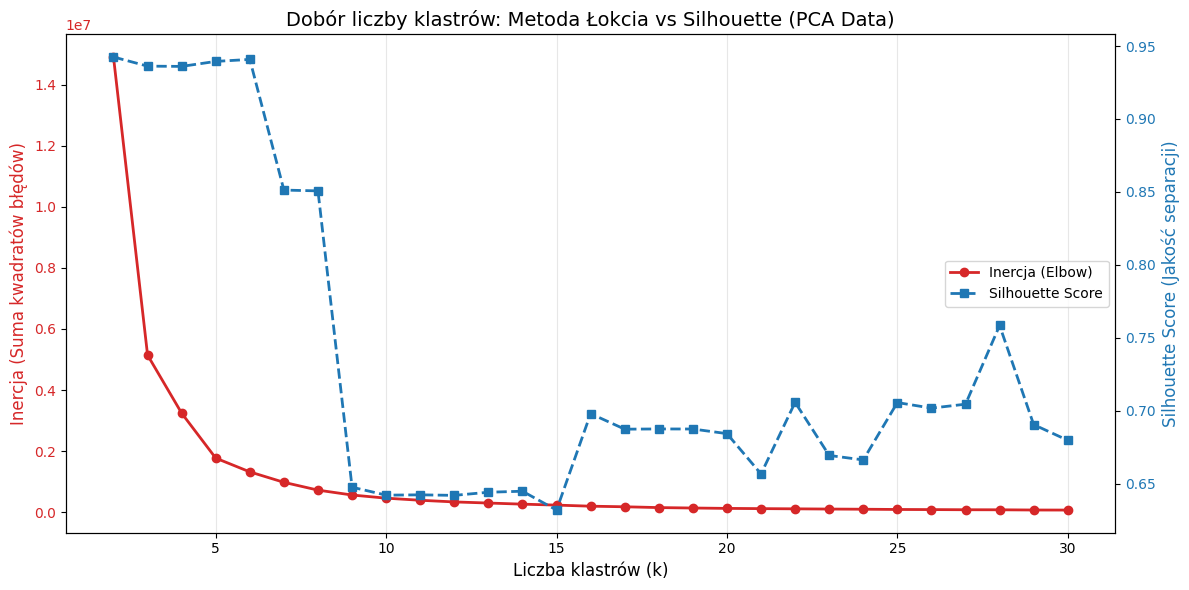

In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np
import os
import warnings

# Ukrywamy irytujące ostrzeżenia scikit-learn o wyciekach pamięci wątków na Windowsie
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.cluster._kmeans")

print("="*80)
print(">>> KROK 3: DOBÓR OPTYMALNEJ LICZBY KLASTRÓW K-MEANS (PCA BASELINE) <<<")
print("="*80)

K_RANGE = range(2, 31) 
inertia = []
sil_scores = []
SAMPLE_SIZE = 15000


if len(X_train_pca) > SAMPLE_SIZE:
    rng = np.random.RandomState(42)
    idx = rng.choice(len(X_train_pca), SAMPLE_SIZE, replace=False)
    X_sample_sil = X_train_pca[idx]
else:
    X_sample_sil = X_train_pca

X_full_inertia = X_train_pca

print(f"[*] Przeszukiwanie przedziału k={K_RANGE.start} do {K_RANGE.stop-1}...")

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_full_inertia)
    
    inertia.append(km.inertia_)
    
    labels_sample = km.predict(X_sample_sil)
    score = silhouette_score(X_sample_sil, labels_sample)
    sil_scores.append(score)
    
    if k % 5 == 0 or k == K_RANGE.start:
        print(f"  -> k={k:<2} | Silhouette={score:.4f} | Inertia={km.inertia_:.0f}")

# ==========================================
# WIZUALIZACJA (Dual Axis)
# ==========================================
fig, ax1 = plt.subplots(figsize=(12, 6))

# Oś Inercji (Metoda Łokcia)
color_inertia = 'tab:red'
ax1.set_xlabel('Liczba klastrów (k)', fontsize=12)
ax1.set_ylabel('Inercja (Suma kwadratów błędów)', color=color_inertia, fontsize=12)
line1 = ax1.plot(K_RANGE, inertia, marker='o', linestyle='-', color=color_inertia, label='Inercja (Elbow)', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color_inertia)
ax1.grid(True, axis='x', alpha=0.3)

# Oś Silhouette
ax2 = ax1.twinx()  
color_sil = 'tab:blue'
ax2.set_ylabel('Silhouette Score (Jakość separacji)', color=color_sil, fontsize=12)
line2 = ax2.plot(K_RANGE, sil_scores, marker='s', linestyle='--', color=color_sil, label='Silhouette Score', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color_sil)

# Połączona legenda
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right')

plt.title('Dobór liczby klastrów: Metoda Łokcia vs Silhouette (PCA Data)', fontsize=14)
plt.tight_layout()

# ==========================================
# ZAPISYWANIE WYKRESU 
# ==========================================
output_dir = '../wykresy'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

file_path = os.path.join(output_dir, '01_kmeans_pca_elbow_silhouette.png')
plt.savefig(file_path, dpi=300, bbox_inches='tight')
print(f"\n[+] SUKCES! Zapisano wykres do pliku: {file_path}")

plt.show()

# KMeans

>>> TRENOWANIE BASELINE: PCA + K-MEANS (K=10) <<<

[*] ROZKŁAD KLASTRÓW:
0    38641
1      379
2     2113
3      152
4      352
5      164
6     1112
7      335
8      799
9    21718
Name: count, dtype: int64
------------------------------
[+] Davies-Bouldin Index: 0.4343 (Im mniej, tym lepiej - ocenia rozproszenie)
[+] Silhouette Score:     0.6394 (Na próbce 10k - ocenia spójność)

[*] Generowanie rzutu 2D dla wizualizacji (PCA 2D)...

[+] SUKCES! Wykres zapisany jako: ../wykresy\02_kmeans_pca_baseline_clusters.png


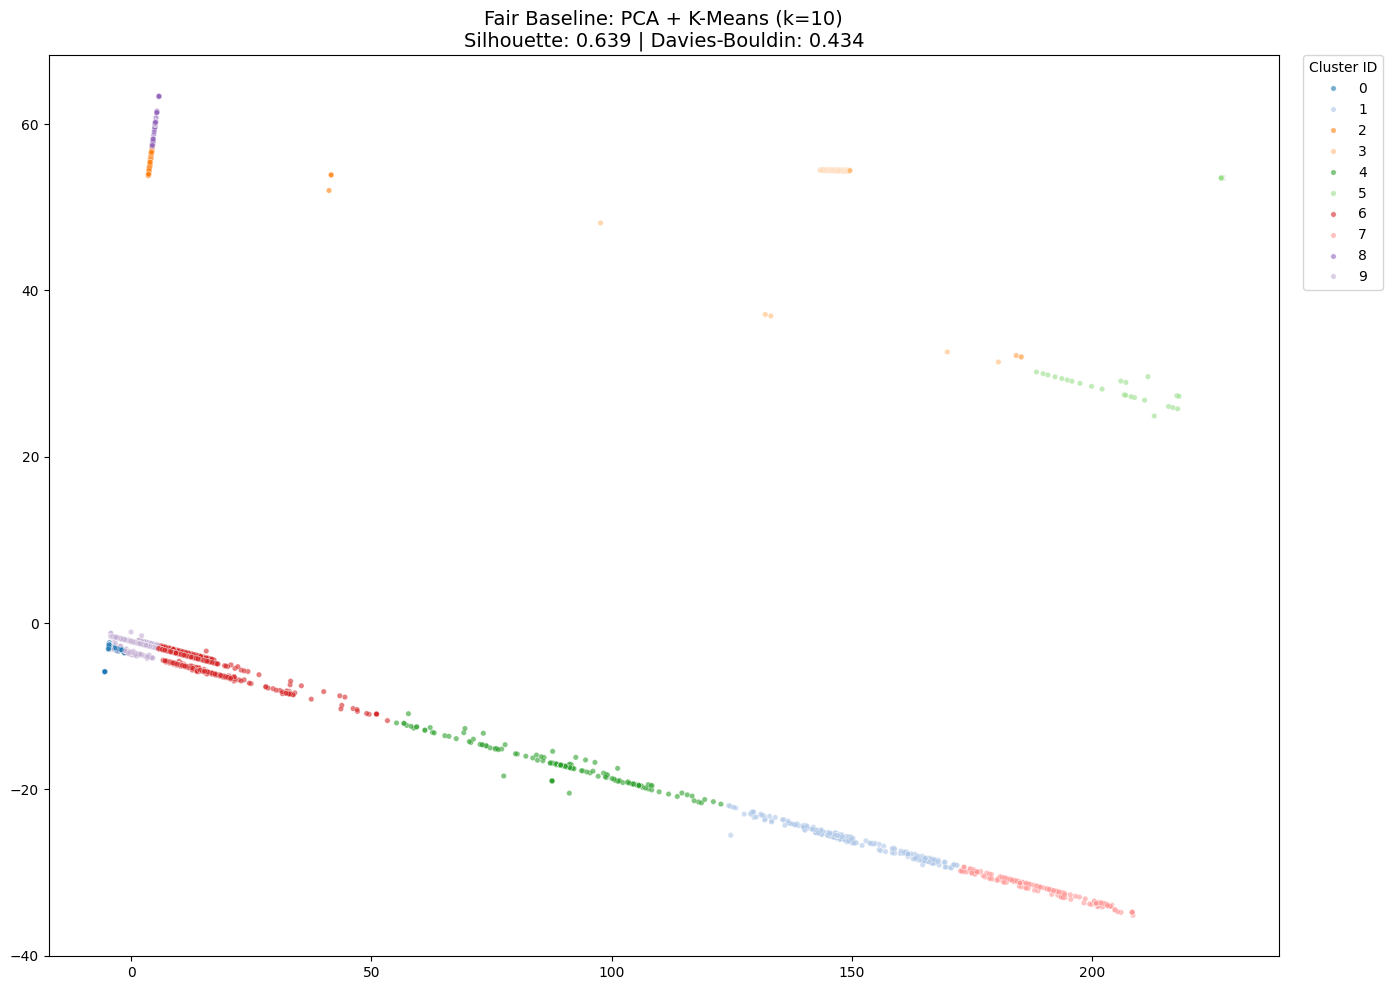

In [4]:
import warnings
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score, silhouette_score
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.cluster._kmeans")

CHOSEN_K = 10
print("="*80)
print(f">>> TRENOWANIE BASELINE: PCA + K-MEANS (K={CHOSEN_K}) <<<")
print("="*80)

# Trenujemy na 10-wymiarowej macierzy PCA
kmeans = KMeans(n_clusters=CHOSEN_K, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_train_pca)

print("\n[*] ROZKŁAD KLASTRÓW:")
cluster_counts = pd.Series(labels_kmeans).value_counts().sort_index()
print(cluster_counts)
print("-" * 30)

# Metryki oceny klastrowania 
db_score = davies_bouldin_score(X_train_pca, labels_kmeans)
print(f"[+] Davies-Bouldin Index: {db_score:.4f} (Im mniej, tym lepiej - ocenia rozproszenie)")

# Próbka dla Silhouette 
idx = np.random.choice(len(X_train_pca), min(10000, len(X_train_pca)), replace=False)
sil_km = silhouette_score(X_train_pca[idx], labels_kmeans[idx])
print(f"[+] Silhouette Score:     {sil_km:.4f} (Na próbce 10k - ocenia spójność)")

# Wizualizacja 2D 
print("\n[*] Generowanie rzutu 2D dla wizualizacji (PCA 2D)...")
if X_train_pca.shape[1] > 2:
    reducer_viz = PCA(n_components=2, random_state=42)
    embedding = reducer_viz.fit_transform(X_train_pca)
else:
    embedding = X_train_pca

plt.figure(figsize=(14, 10))
sns.scatterplot(
    x=embedding[:, 0], y=embedding[:, 1],
    hue=labels_kmeans, palette='tab20',      
    s=15, alpha=0.6, legend='full'
)

plt.title(f"Fair Baseline: PCA + K-Means (k={CHOSEN_K})\nSilhouette: {sil_km:.3f} | Davies-Bouldin: {db_score:.3f}", fontsize=14)
plt.legend(bbox_to_anchor=(1.02, 1), loc=2, borderaxespad=0., title="Cluster ID")
plt.tight_layout()

# Zapis do pliku
output_dir = '../wykresy'
if not os.path.exists(output_dir): os.makedirs(output_dir)
filename = os.path.join(output_dir, '02_kmeans_pca_baseline_clusters.png')
plt.savefig(filename, dpi=300, bbox_inches='tight')
print(f"\n[+] SUKCES! Wykres zapisany jako: {filename}")
plt.show()